In [7]:
import mdtraj as md

# 1. 只留 A 链 Cα
def load_a_ca(pdb):
    t = md.load(pdb)
    idx = t.top.select('chainid 0 and backbone')
    return t.atom_slice(idx)

ref   = load_a_ca('PAC5_Rep2_36.4.pdb')
RNA   = load_a_ca('RNA_Rep3_394.3.pdb')
ssDNA = load_a_ca('ssDNA_Rep3_203.6.pdb')
# 2. 叠合 & 算 RMSD（Å）
RNA.superpose(ref)                  # 把 pose 叠到 ref
rmsd_angstrom = md.rmsd(RNA, ref) * 10   # nm→Å
print('PAC5-RNA RMSD (Å):', rmsd_angstrom[0])

ssDNA.superpose(ref)                  # 把 pose 叠到 ref
rmsd_angstrom = md.rmsd(ssDNA, ref) * 10   # nm→Å
print('PAC5-ssDNA RMSD (Å):', rmsd_angstrom[0])

PAC5-RNA RMSD (Å): 2.9989185
PAC5-ssDNA RMSD (Å): 2.7184982


[[0.         2.95088196 2.70770264]
 [2.95088196 0.         2.4178381 ]
 [2.70770264 2.4178381  0.        ]]
Done! rmsd_matrix.txt + rmsd_heatmap.png 已生成


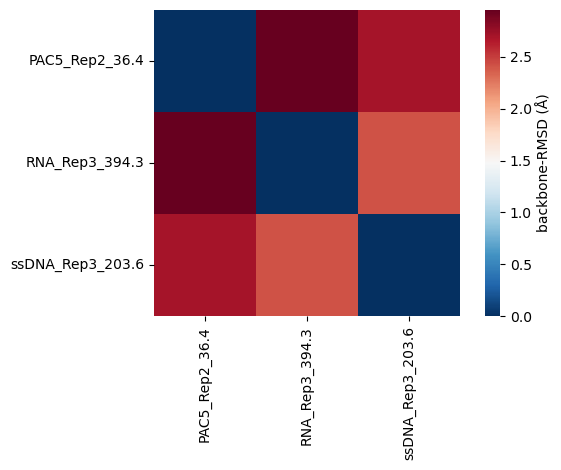

In [2]:
import glob, numpy as np, mdtraj as md, seaborn as sns, matplotlib.pyplot as plt

pdb_files = sorted(glob.glob('*.pdb'))
top = md.load(pdb_files[0]).topology
bb_idx = top.select('name CA')          # 或 'name CA' 只选 Cα

traj = md.join([md.load(pdb, atom_indices=bb_idx) for pdb in pdb_files])
traj.superpose(traj, frame=0)            # 先叠合

n = traj.n_frames
matrix = np.empty((n, n))
for i in range(n):
    matrix[i] = md.rmsd(traj, traj, frame=i) * 10
print(matrix)

# 保存
np.savetxt('rmsd_matrix.txt', matrix, fmt='%.2f')
with open('rmsd_labels.txt', 'w') as f:
    for name in pdb_files:
        f.write(name[:-4] + '\n')

# 10 秒出图
labels = [name[:-4] for name in pdb_files]
sns.heatmap(matrix, xticklabels=labels, yticklabels=labels,
            cmap='RdBu_r', square=True, cbar_kws={'label': 'backbone-RMSD (Å)'})
plt.tight_layout()
# plt.savefig('rmsd_heatmap.png', dpi=300)
print('Done! rmsd_matrix.txt + rmsd_heatmap.png 已生成')

[[0.         0.2950882  0.27077025]
 [0.2950882  0.         0.2417838 ]
 [0.27077025 0.2417838  0.        ]]
Done! rmsd_matrix.txt + rmsd_heatmap.png 已生成


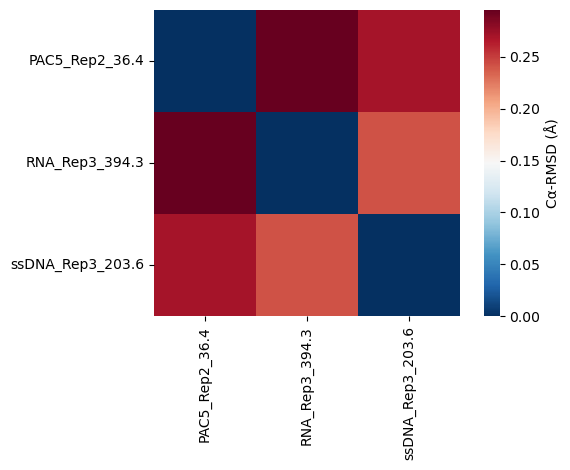

In [9]:
import glob, numpy as np, mdtraj as md, seaborn as sns, matplotlib.pyplot as plt

pdb_files = sorted(glob.glob('*.pdb'))
top = md.load(pdb_files[0]).topology
bb_idx = top.select('name CA')          # 或 'name CA' 只选 Cα

traj = md.join([md.load(pdb, atom_indices=bb_idx) for pdb in pdb_files])
traj.superpose(traj, frame=0)            # 先叠合

n = traj.n_frames
matrix = np.empty((n, n))
for i in range(n):
    matrix[i] = md.rmsd(traj, traj, frame=i)
print(matrix)

# 保存
np.savetxt('rmsd_matrix.txt', matrix, fmt='%.2f')
with open('rmsd_labels.txt', 'w') as f:
    for name in pdb_files:
        f.write(name[:-4] + '\n')

# 10 秒出图
labels = [name[:-4] for name in pdb_files]
sns.heatmap(matrix, xticklabels=labels, yticklabels=labels,
            cmap='RdBu_r', square=True, cbar_kws={'label': 'Cα-RMSD (Å)'})
plt.tight_layout()
# plt.savefig('rmsd_heatmap.png', dpi=300)
print('Done! rmsd_matrix.txt + rmsd_heatmap.png 已生成')

In [15]:
import MDAnalysis as mda

ModuleNotFoundError: No module named 'MDAnalysis'

In [13]:
import glob, numpy as np, mdtraj as md, seaborn as sns, matplotlib.pyplot as plt


import glob, numpy as np, mdtraj as md

pdb_files = sorted(glob.glob('*.pdb'))
top = md.load(pdb_files[0]).topology
idx = top.select('backbone')          # 或 'name CA'

traj = md.join([md.load(pdb, atom_indices=idx) for pdb in pdb_files])
traj.superpose(traj, frame=0)         # 先叠合

# 向量化：所有帧 vs 所有帧
matrix = md.rmsd(traj, traj[:, :, :])   # 参考轨迹维度被广播 -> (n, n)
print(matrix)

# 保存
np.savetxt('rmsd_matrix.txt', matrix, fmt='%.2f')
with open('rmsd_labels.txt', 'w') as f:
    for name in pdb_files:
        f.write(name[:-4] + '\n')

# 10 秒出图
labels = [name[:-4] for name in pdb_files]
sns.heatmap(matrix, xticklabels=labels, yticklabels=labels,
            cmap='RdBu_r', square=True, cbar_kws={'label': 'Cα-RMSD (Å)'})
plt.tight_layout()
# plt.savefig('rmsd_heatmap.png', dpi=300)
print('Done! rmsd_matrix.txt + rmsd_heatmap.png 已生成')

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed